In [17]:
import mne
import numpy as np
import re

def clean_channel_names(raw):
    mapping = {}
    for ch_name in raw.ch_names:
        # 1. 특수문자 및 불필요한 접미사 제거 (더 강력하게)
        # 예: "EEG Fp1-REF" -> "Fp1", "C3-M1" -> "C3"
        clean_name = re.sub(r'(?i)(EEG|[-_]?(REF|LE|MON|AVG|M1|M2|A1|A2)$)', '', ch_name).strip()
        clean_name = clean_name.upper()
        
        # 2. 표준 이름 매핑 (필요한 경우 추가)
        name_map = {
            'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz', 'OZ': 'Oz',
            'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8',
            'T7': 'T7', 'T8': 'T8' # 이미 표준인 경우 유지
        }
        final_name = name_map.get(clean_name, clean_name.capitalize()) # 나머지는 첫글자만 대문자로
        
        # 원본 이름과 다르면 매핑에 추가
        if ch_name != final_name:
            mapping[ch_name] = final_name

    # 중복 이름 방지 (예: T3->T7로 바꿨는데 이미 T7이 있는 경우)
    # MNE rename_channels는 중복을 허용하지 않으므로, 있는 이름은 제외하고 변경
    final_mapping = {k: v for k, v in mapping.items() if v not in raw.ch_names or k == v}
    
    try:
        raw.rename_channels(final_mapping)
    except Exception as e:
        pass # 이름 변경 실패 시 경고 없이 넘어감 (좌표 매핑에서 걸러짐)
    return raw

def get_valid_channel_indices(raw):
    valid_names = []
    valid_coords = []
    
    # 몽타주 정보에서 좌표 추출
    for ch_name in raw.ch_names:
        if ch_name not in raw.info['chs'][raw.ch_names.index(ch_name)]['ch_name']:
            continue
            
        # MNE 내부 좌표 가져오기
        ch_idx = raw.ch_names.index(ch_name)
        loc = raw.info['chs'][ch_idx]['loc'][:3]
        
        # 좌표가 유효한지 확인 (NaN이 아니고, 0,0,0이 아닌 경우)
        if not np.all(np.isnan(loc)) and not np.all(loc == 0):
            valid_names.append(ch_name)
            valid_coords.append(loc)
            
    return valid_names, valid_coords

unwanted_chs = ['Roc', 'Loc', 'Ekg1', 'Photic', 'Ibi', 'Bursts', 'Suppr']

path = r'D:\One_한양대학교\private object minsu\coding\data\TUAB\v3.0.1\edf\eval\abnormal\01_tcp_ar'
raw = mne.io.read_raw_edf(path + r'\aaaaabdo_s003_t000.edf', preload=False, verbose=False)
raw = clean_channel_names(raw)
raw.drop_channels(unwanted_chs)
raw.pick("eeg", exclude="bads")
# raw.ch_names
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False, on_missing='ignore')
valid_names, valid_coords = get_valid_channel_indices(raw)
bb = raw.get_data()
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz', 'Oz']
import mne
import numpy as np
import re

def clean_channel_names(raw):
    mapping = {}
    for ch_name in raw.ch_names:
        # 1. 특수문자 및 불필요한 접미사 제거 (더 강력하게)
        # 예: "EEG Fp1-REF" -> "Fp1", "C3-M1" -> "C3"
        clean_name = re.sub(r'(?i)(EEG|[-_]?(REF|LE|MON|AVG|M1|M2|A1|A2)$)', '', ch_name).strip()
        clean_name = re.sub(r'[^A-Za-z0-9]', '', ch_name).strip().upper()
        # clean_name = clean_name.upper()
        
        # 2. 표준 이름 매핑 (필요한 경우 추가)
        name_map = {
            'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz', 'OZ': 'Oz',
            'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8',
            'T7': 'T7', 'T8': 'T8' # 이미 표준인 경우 유지
        }
        final_name = name_map.get(clean_name, clean_name.capitalize()) # 나머지는 첫글자만 대문자로
        
        # 원본 이름과 다르면 매핑에 추가
        if ch_name != final_name:
            mapping[ch_name] = final_name

    # 중복 이름 방지 (예: T3->T7로 바꿨는데 이미 T7이 있는 경우)
    # MNE rename_channels는 중복을 허용하지 않으므로, 있는 이름은 제외하고 변경
    final_mapping = {k: v for k, v in mapping.items() if v not in raw.ch_names or k == v}
    
    try:
        raw.rename_channels(final_mapping)
    except Exception as e:
        pass # 이름 변경 실패 시 경고 없이 넘어감 (좌표 매핑에서 걸러짐)
    return raw

def get_valid_channel_indices(raw):
    valid_names = []
    valid_coords = []
    
    # 몽타주 정보에서 좌표 추출
    for ch_name in raw.ch_names:
        if ch_name not in raw.info['chs'][raw.ch_names.index(ch_name)]['ch_name']:
            continue
            
        # MNE 내부 좌표 가져오기
        ch_idx = raw.ch_names.index(ch_name)
        loc = raw.info['chs'][ch_idx]['loc'][:3]
        
        # 좌표가 유효한지 확인 (NaN이 아니고, 0,0,0이 아닌 경우)
        if not np.all(np.isnan(loc)) and not np.all(loc == 0):
            valid_names.append(ch_name)
            valid_coords.append(loc)
            
    return valid_names, valid_coords

unwanted_chs = ['Roc', 'Loc', 'Ekg1', 'Photic', 'Ibi', 'Bursts', 'Suppr', 'Ecg ekg', 'Pulse rate', 'Ibi']

# path = r'D:\One_한양대학교\private object minsu\coding\data\TUAB\v3.0.1\edf\train\abnormal\01_tcp_ar'
# raw = mne.io.read_raw_edf(path + r'\aaaaaaaq_s004_t000.edf', preload=False, verbose=False)
# raw = mne.io.read_raw_edf(path + r'\aaaaajsl_s010_t000.edf', preload=False, verbose=False)


path = r'D:\open_eeg_eval\physionet_MI\S001'
raw = mne.io.read_raw_edf(path + r'\S001R03.edf', preload=False, verbose=False)

raw = clean_channel_names(raw)
print(raw.ch_names)
raw.drop_channels([f for f in unwanted_chs if f in raw.ch_names])
raw.pick("eeg", exclude="bads")
# raw.ch_names
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False, on_missing='ignore')
print(raw.ch_names)
valid_names, valid_coords = get_valid_channel_indices(raw)
bb = raw.get_data()
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz', 'Oz']
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz']
print(raw.ch_names)
print(valid_names)
raw.get_data()[-1]

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7

array([-2.8e-05, -4.0e-05, -3.7e-05, ...,  0.0e+00,  0.0e+00,  0.0e+00])

In [18]:
mne.events_from_annotations(raw, )

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


(array([[    0,     0,     1],
        [  672,     0,     3],
        [ 1328,     0,     1],
        [ 2000,     0,     2],
        [ 2656,     0,     1],
        [ 3328,     0,     2],
        [ 3984,     0,     1],
        [ 4656,     0,     3],
        [ 5312,     0,     1],
        [ 5984,     0,     3],
        [ 6640,     0,     1],
        [ 7312,     0,     2],
        [ 7968,     0,     1],
        [ 8640,     0,     2],
        [ 9296,     0,     1],
        [ 9968,     0,     3],
        [10624,     0,     1],
        [11296,     0,     2],
        [11952,     0,     1],
        [12624,     0,     3],
        [13280,     0,     1],
        [13952,     0,     3],
        [14608,     0,     1],
        [15280,     0,     2],
        [15936,     0,     1],
        [16608,     0,     2],
        [17264,     0,     1],
        [17936,     0,     3],
        [18592,     0,     1],
        [19264,     0,     2]]),
 {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3})

In [5]:
import pandas as pd
import numpy as np
path = r"D:\open_eeg_eval\ISRUC\dataset\Non_Events\non_event_batch_1\S1_p1_Stagen1_Event10_Session1.csv"
df = pd.read_csv(path)
df = np.array([df['C3-A2'], df['F3-A2']])

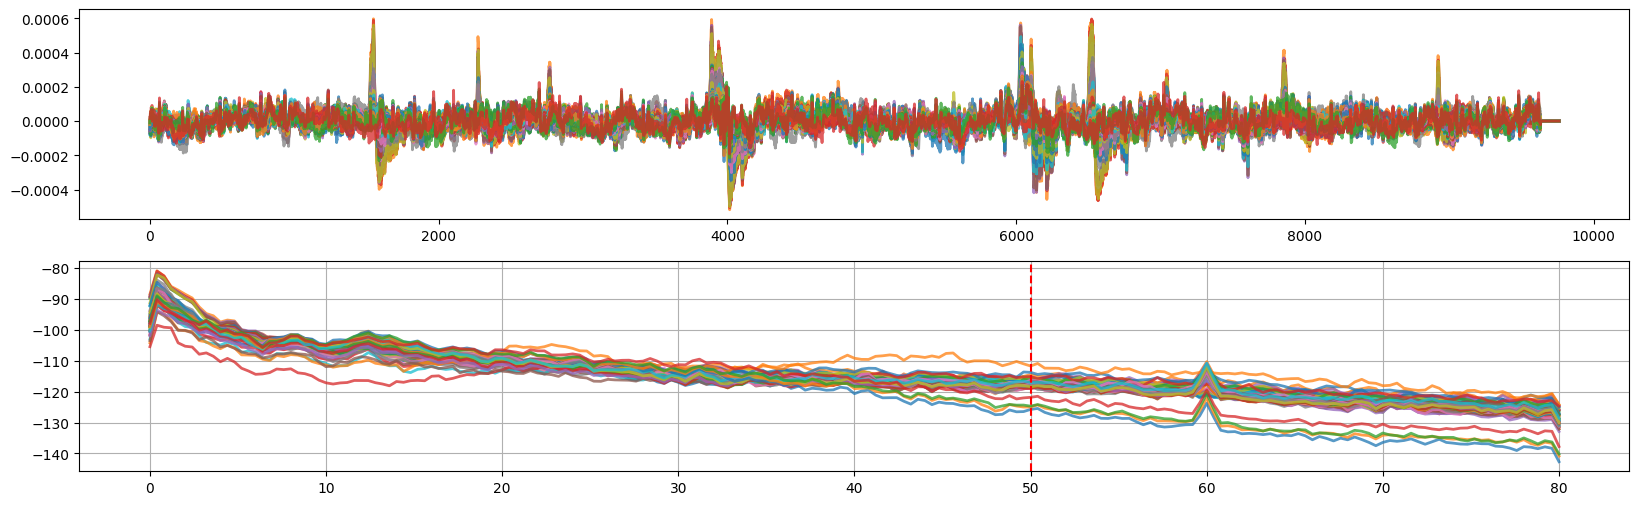

In [11]:
import matplotlib.pyplot as plt
from scipy import signal
plt.figure(figsize=(20,6))
plt.subplot(211)
plt.plot(bb[:, 200*0:200*60].T, alpha=0.75, lw=2) ############### 여기서 index 바꾸면 세그먼트 내 구간 plot 가능
plt.subplot(212)
freqs, psd = signal.welch(bb, fs=raw.info['sfreq'], nperseg=200*2, axis=-1)
# psd = np.mean(psd, axis=0)) ############### 이거 주석 풀면 mean psd 볼 수 있음 
plt.plot(freqs, (10 * np.log10(psd)).T, alpha=0.75, lw=2)
plt.axvline(x=50, color='r', linestyle='--')
plt.grid()
print()

[[-0.0309    0.11456   0.02786 ]
 [ 0.02841   0.11536   0.02773 ]
 [-0.05182   0.0867    0.07874 ]
 [ 0.05026   0.08746   0.0773  ]
 [-0.0719    0.0731    0.02579 ]
 [ 0.0714    0.0745    0.0251  ]
 [-0.086     0.01487   0.03117 ]
 [ 0.08325   0.01526   0.03098 ]
 [-0.06714   0.02336   0.1045  ]
 [ 0.0653    0.02357   0.1037  ]
 [-0.07446  -0.0421    0.04126 ]
 [ 0.07104  -0.04227   0.0412  ]
 [-0.05502  -0.04422   0.0999  ]
 [ 0.05365  -0.04434   0.1005  ]
 [-0.0316   -0.08057   0.05478 ]
 [ 0.02768  -0.0805    0.05475 ]
 [-0.001229  0.09326   0.10266 ]
 [-0.001374  0.02762   0.1403  ]
 [-0.001709 -0.04523   0.1267  ]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


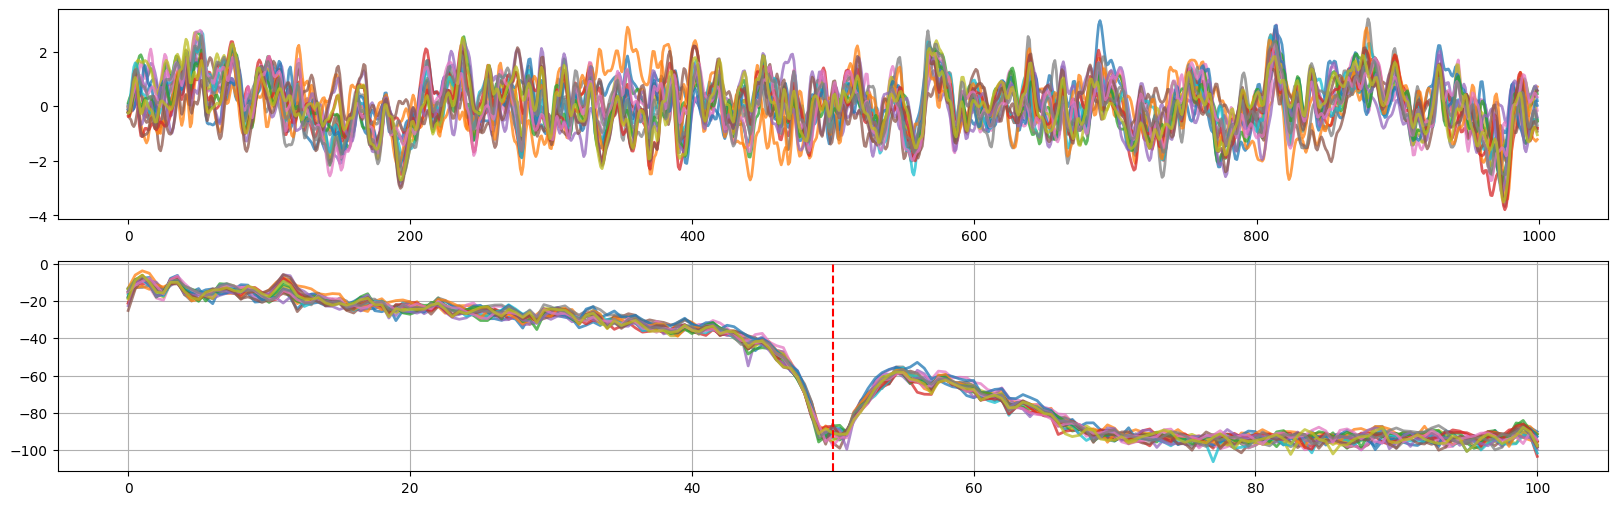

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

task = "mat"

path = f"D:\\open_eeg_eval\\{task}_npy\\test\\"
data = np.load(path + "eeg.npy")
bb = data[0]
plt.figure(figsize=(20,6))
plt.subplot(211)
plt.plot(bb[:, 200*0:200*60].T, alpha=0.75, lw=2) ############### 여기서 index 바꾸면 세그먼트 내 구간 plot 가능
plt.subplot(212)
freqs, psd = signal.welch(bb, fs=200, nperseg=200*2, axis=-1)
# psd = np.mean(psd, axis=0)) ############### 이거 주석 풀면 mean psd 볼 수 있음 
plt.plot(freqs, (10 * np.log10(psd)).T, alpha=0.75, lw=2)
plt.axvline(x=50, color='r', linestyle='--')
plt.grid()
coords = np.load(path + "coords.npy")
print(coords[0])
labels = np.load(path + "label.npy")
print(labels)

In [4]:
import mne

path = 'D:\\open_eeg\\physionet_HMC\\recordings\\SN001.edf'
raw = mne.io.read_raw_edf(path, preload=True)
path = 'D:\\open_eeg\\physionet_HMC\\recordings\\SN001_sleepscoring.edf'
annotations = mne.read_annotations(path)
raw.set_annotations(annotations)
print(raw.info)
print(raw.ch_names)
events, event_dict = mne.events_from_annotations(raw)
data = raw.get_data()

Extracting EDF parameters from D:\open_eeg\physionet_HMC\recordings\SN001.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6566399  =      0.000 ... 25649.996 secs...


C:\Users\user\AppData\Local\Temp\ipykernel_40208\2521569841.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(path, preload=True)
C:\Users\user\AppData\Local\Temp\ipykernel_40208\2521569841.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(path, preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG F4-M1, EEG C4-M1, EEG O2-M1, EEG C3-M2, EMG chin, EOG E1-M2, ...
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 1.0 Hz
 lowpass: 35.0 Hz
 meas_date: 2001-01-01 23:59:30 UTC
 nchan: 8
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: SN001, sex: 0, last_name: X>
>
['EEG F4-M1', 'EEG C4-M1', 'EEG O2-M1', 'EEG C3-M2', 'EMG chin', 'EOG E1-M2', 'EOG E2-M2', 'ECG']
Used Annotations descriptions: [np.str_('Lights off@@EEG F4-A1'), np.str_('Lights on@@EEG Fpz-Cz'), np.str_('Sleep stage N1'), np.str_('Sleep stage N2'), np.str_('Sleep stage N3'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]


In [3]:
import mne

path = 'D:\\One_한양대학교\\private object minsu\\coding\\data\\TUAB\\v3.0.1\\edf\\train\\abnormal\\01_tcp_ar\\aaaaaaaq_s004_t000.edf'
raw = mne.io.read_raw_edf(path, preload=True)

print(raw.info)
print(raw.ch_names)
events, event_dict = mne.events_from_annotations(raw)
data = raw.get_data()

Extracting EDF parameters from D:\One_한양대학교\private object minsu\coding\data\TUAB\v3.0.1\edf\train\abnormal\01_tcp_ar\aaaaaaaq_s004_t000.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 338999  =      0.000 ...  1355.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 30 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2012-01-01 00:00:00 UTC
 nchan: 30
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: aaaaaaaq, sex: 2, last_name: aaaaaaaq>
>
['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG A1-REF', 'EEG A2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG ROC-REF', 'EEG LOC-REF', 'EEG EKG1-REF', 'EEG T1-REF', 'EEG T2-REF', 'PHOTIC-REF', 'IB

In [8]:
import numpy as np

task = "mat"
path = f"D:\\open_eeg_eval\\{task}_npy\\"
num_seg = 0
for key in ["test", "train", "val"]:
    num_seg += np.load(path + f"{key}//eeg.npy").shape[0]
print(num_seg)

1659


In [14]:
import mne

all_seg = 0
for j in range(1,36):
    for i in range(1,3):
        
        temp = '0' + str(j) if j < 10 else str(j)
        path = f'D:\\open_eeg\\mat\\Subject{temp}_{i}.edf'
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

        # print(raw.info)
        # print(raw.ch_names)
        events, event_dict = mne.events_from_annotations(raw)
        data = raw.get_data()
        seg_count = (data.shape[1]/500)//5
        flag = "" if i==1 else "\n"
        all_seg += seg_count
        print(f"{j}_{i}: {seg_count}         ", end=flag)
print(f"Total segments: {all_seg}")

1_1: 36.0         1_2: 12.0         
2_1: 36.0         2_2: 12.0         
3_1: 36.0         3_2: 12.0         
4_1: 34.0         4_2: 12.0         
5_1: 36.0         5_2: 12.0         
6_1: 36.0         6_2: 12.0         
7_1: 36.0         7_2: 12.0         
8_1: 36.0         8_2: 12.0         
9_1: 36.0         9_2: 12.0         
10_1: 37.0         10_2: 12.0         
11_1: 36.0         11_2: 12.0         
12_1: 36.0         12_2: 12.0         
13_1: 36.0         13_2: 12.0         
14_1: 36.0         14_2: 12.0         
15_1: 36.0         15_2: 12.0         
16_1: 36.0         16_2: 12.0         
17_1: 36.0         17_2: 12.0         
18_1: 36.0         18_2: 12.0         
19_1: 36.0         19_2: 12.0         
20_1: 36.0         20_2: 12.0         
21_1: 36.0         21_2: 12.0         
22_1: 36.0         22_2: 12.0         
23_1: 36.0         23_2: 12.0         
24_1: 36.0         24_2: 12.0         
25_1: 36.0         25_2: 12.0         
26_1: 36.0         26_2: 12.0         
27_1